# Cinética de Procesos (Sesión 04)

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad, trapezoid
import src.ratelaws as rate

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 2 Reacciones paralelas

## 2.1 Ejemplo

### 2.1.1 Planteamiento

**Reacciones de Trambouze:**

    Fogler, Ex.8.1

El reactivo $\mathrm{A}$ se descompone mediante tres reacciones simultaneas en tres productos diferentes. Uno es deseable, $\mathrm{B}$, y los otros dos no, $\mathrm{X}$, $\mathrm{Y}$. A estas reacciones en fase gaseosa, junto con leyes de reacción apropiadas, se les conoce como reacciones de Trambouze.

$$\begin{matrix*}[l]
\mathrm{A} \xrightarrow[]{k_1} \mathrm{X} & \quad & -r_{\mathrm{A}_1} = r_{\mathrm{X}} = k_1 = 0.0001 \left[\mathrm{mol.dm^{-3}.s^{-1}}\right] \\
\mathrm{A} \xrightarrow[]{k_2} \mathrm{B} & \quad & -r_{\mathrm{A}_2} = r_{\mathrm{B}} = k_2 C_{\mathrm{A}} = \left(0.0015 \, \mathrm{s^{-1}}\right) C_{\mathrm{A}} \\
\mathrm{A} \xrightarrow[]{k_3} \mathrm{Y} & \quad & -r_{\mathrm{A}_3} = r_{\mathrm{Y}} = k_3 C_{\mathrm{A}}^2 = \left(0.008 \, \mathrm{dm^{3}.mol^{-1}.s^{-1}}\right) C_{\mathrm{A}}^2 \\
\end{matrix*}$$

$$r_{\mathrm{A}} = r_{\mathrm{A}_1} + r_{\mathrm{A}_2} + r_{\mathrm{A}_3}$$

Las tasas de reacción específicas se dan a $300$ $[\mathrm{K}]$, y las energías de activación correspondientes son: $10000$, $15000$, y $20000$ $[\mathrm{kcal.mol}]$, respectivamente.

In [111]:
# Global problem definition
cA0 = 0.4 # [mol.dm-3]
species = ["A", "X", "B", "Y"]
T = 300 # K
k1, k2, k3 = 1e-4, 1.5e-3, 8e-3 # kinetic constants @ 300 K
n1, n2, n3 = 0.0, 1.0, 2.0 # orders
E1, E2, E3 = 1e4, 1.5e4, 2e4 # activation energies
Q = 2.0 # volumetric flow, [dm3.s-1]

# kinetic constants k(T)
R=8.314
def kr(T, kr, Tr, Ea):
    k0 = kr / np.exp(-Ea/(R*Tr))
    return k0 * np.exp(-Ea/(R*T))
k_1 = lambda T: kr(T, k1, 300, E1)
k_2 = lambda T: kr(T, k2, 300, E2)
k_3 = lambda T: kr(T, k3, 300, E3)

# reaction rate laws
r_X = lambda cA, T: k_1(T)*cA**(0)
r_B = lambda cA, T: k_2(T)*cA
r_Y = lambda cA, T: k_3(T)*cA**(2)

r_A = lambda cA, T: -k_1(T) - k_2(T)*cA - k_3(T)*cA**(2)
r_A_inv = lambda cA, T: 1/ r_A(cA, T)

### 2.1.2 Problemática (1)

**¿Bajo que condiciones (e.g. tipo de reactores, temperatura, concentraciones), se debe llevar a cabo la reacción para maximizar la selectividad de la especie $\mathrm{B}$, para una concentración inicial de $C_{\mathrm{A}} = 0.4\,M$, y un flujo volumétrico de $2.0$ $\mathrm{dm^{3}.s^{-1}}$?**

##### Efecto de la temperatura en la selectividad

In [112]:
cA = np.linspace(cA0, 0, 1000)
xA = 1 - cA/cA0

La selectividad instantanea de la especie $\mathrm{B}$ con respecto a las especies $\mathrm{X,Y}$ es:

$$S_{_{\mathrm{B/XY}}} = \frac{r_{\mathrm{B}}}{r_{\mathrm{X}} + r_{\mathrm{Y}}} = \frac{k_2 C_{\mathrm{A}}}{k_1 + k_3 C_{\mathrm{A}}^2}$$

**Efecto de la temperatura**:

- Selectividad: Independiente de la temperatura (en este ejemplo).
- Conversión: Incrementa con la temperatura.

T      cA*    X*     S(i)
--------------------------
250.0  0.167  0.583  0.839
300.0  0.112  0.721  0.839
350.0  0.084  0.790  0.839
400.0  0.068  0.831  0.839


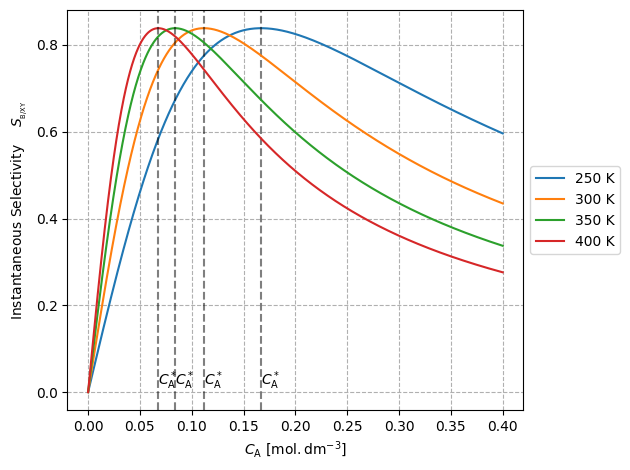

In [113]:
fig, ax = plt.subplots()
Temps = [250, 300, 350, 400]
print("T      cA*    X*     S(i)")
print("--------------------------")
for Temp in Temps:
    S = (r_B(cA,Temp)) / (r_X(cA,Temp) + r_Y(cA,Temp))
    indS = np.argmax(S)
    cAs = cA[indS]
    Xs = (cA0 - cAs) / cA0
    ax.plot(cA, S, label=f"{Temp} K")
    ax.axvline(cAs, ls='--', c='k', alpha=0.5)
    ax.annotate(r"$C_{\mathrm{A}}^*$", fontweight='bold', xy=(cAs, 0), ha='left', va='bottom')
    print(f"{Temp:.1f}  {cAs:.3f}  {Xs:.3f}  {S[indS]:.3f}")
ax.set_xlabel(r"$C_{\mathrm{A}}$ $[\mathrm{mol.dm^{-3}}]$")
ax.set_ylabel(r"Instantaneous Selectivity    $S_{_{\mathrm{B/XY}}}$")
ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax.grid(ls='--')
fig.tight_layout()
plt.show()

##### Reactor Batch

**Reactor Batch**

**Ecuación de diseño**

$$\tau = -\int_{C_{\mathrm{A_0}}}^{C_{\mathrm{A}}} \frac{dC_{\mathrm{A}}}{-r_{\mathrm{A}}} = N_{\mathrm{A}_0} \int_{0}^{X} \frac{dX}{-r_{\mathrm{A}} V} $$

**Curvas cinéticas y conversión**

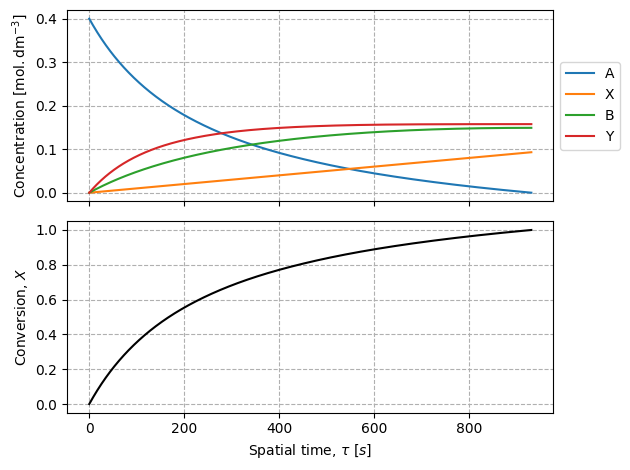

In [114]:
def batch(t, C):
    dC_dt = np.array([
        r_A(C[0], T),
        r_X(C[0], T), #rX
        r_B(C[0], T), #rB
        r_Y(C[0], T)  #rY
    ])
    return dC_dt
def batchEnd(t, C):
    return C[0]
batchEnd.terminal = True

eps = 0.0
C0 = (cA0, eps, eps, eps) # concentration [mol.dm-3]
t_span = (0, 1000)
dt = 1
t_eval = np.arange(t_span[0], t_span[1]+dt, dt)
sol = solve_ivp(
    batch, 
    t_span, 
    y0=C0, 
    events=batchEnd, 
    t_eval=t_eval
)
X = (cA0 - sol.y[0])/cA0 # conversion

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, sol.y):
    ax0.plot(sol.t, y, label=specie)
ax1.plot(sol.t, X, color='k')
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Concentration [$\mathrm{mol.dm^{-3}}$]")
ax1.set_ylabel(r"Conversion, $X$")
ax1.set_xlabel(r"Spatial time, $\tau$ [$s$]")
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

**Selectividad**

En el reactor Batch, las selectividades instantanea y global son diferentes.

Selectividad instantanea   : X*= 0.72, S*= 0.84
Selectividad global (Batch): X*= 0.87, S*= 0.64



/tmp/ipykernel_18579/2486005052.py:5: RuntimeWarning: invalid value encountered in divide
  selIns, selOvr = rB / (rX + rY), cB / (cX + cY)


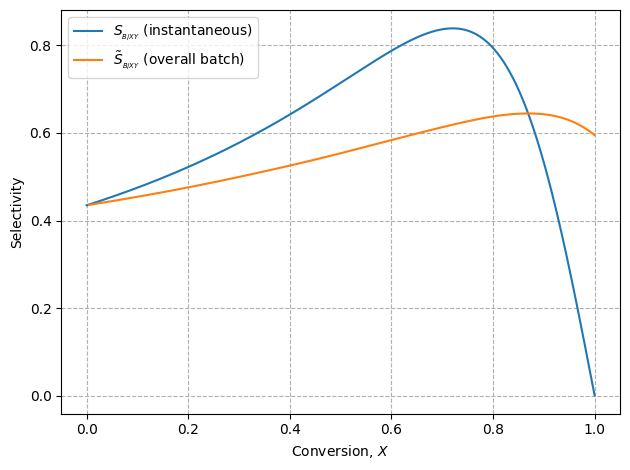

In [115]:
# calculo selectividades
rates = batch(sol.t, sol.y)
rX, rB, rY = rates[1], rates[2], rates[3]
cX, cB, cY = sol.y[1], sol.y[2], sol.y[3]
selIns, selOvr = rB / (rX + rY), cB / (cX + cY)
indIns, indOvr = np.nanargmax(selIns), np.nanargmax(selOvr)
print(f"Selectividad instantanea   : X*= {X[indIns]:.2f}, S*= {selIns[indIns]:.2f}")
print(f"Selectividad global (Batch): X*= {X[indOvr]:.2f}, S*= {selOvr[indOvr]:.2f}")
print(f"")

# Grafico
fig, ax = plt.subplots()
ax.plot(X, selIns, label=r"$S_{_{B/XY}}$ (instantaneous)") # instantaneous
ax.plot(X, selOvr, label=r"$\tilde{S}_{_{B/XY}}$ (overall batch)") # overall
ax.set_ylabel(r"Selectivity")
ax.set_xlabel(r"Conversion, $X$")
ax.grid(ls='--')
ax.legend()
fig.tight_layout()
plt.show()

##### Reactor CSTR

**Reactor CSTR:**

El uso de este reactor es adecuado, dado que el contenido total del mismo estará operando a una conversión $X^{*}$ que maximice la selectividad.

**Ecuación de diseño**:

$$\tau = \frac{V}{\dot{Q}} = \frac{\left(C_{\mathrm{A}}^{0} - C_{\mathrm{A}}^{*}\right)}{-r_{\mathrm{A}}^{*}} = \frac{C_{\mathrm{A}}^0 X^{*}}{-r_{\mathrm{A}}^{*}}$$

**Curvas cinéticas y conversión**

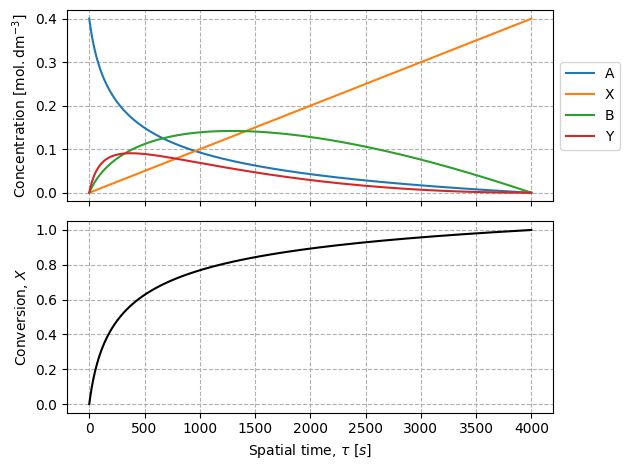

In [116]:
cstrTau = (cA0 - cA) / (-r_A(cA, T))
cstrV = Q * cstrTau

# concentraciones
cX = cstrTau * r_X(cA, T) 
cB = cstrTau * r_B(cA, T)
cY = cstrTau * r_Y(cA, T)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, c in zip(species, [cA, cX, cB, cY]):
    ax0.plot(cstrTau, c, label=specie)
ax1.plot(cstrTau, xA, color='k')
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Concentration [$\mathrm{mol.dm^{-3}}$]")
ax1.set_ylabel(r"Conversion, $X$")
ax1.set_xlabel(r"Spatial time, $\tau$ [$s$]")
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

**Selectividad**

Las selectividades instantanea y global son iguales.

Selectividad instantanea  : X*= 0.72, S*= 0.84
Selectividad global (CSTR): X*= 0.72, S*= 0.84



/tmp/ipykernel_18579/2503861177.py:3: RuntimeWarning: invalid value encountered in divide
  selIns, selOvr = rB / (rX + rY), cB / (cX + cY)


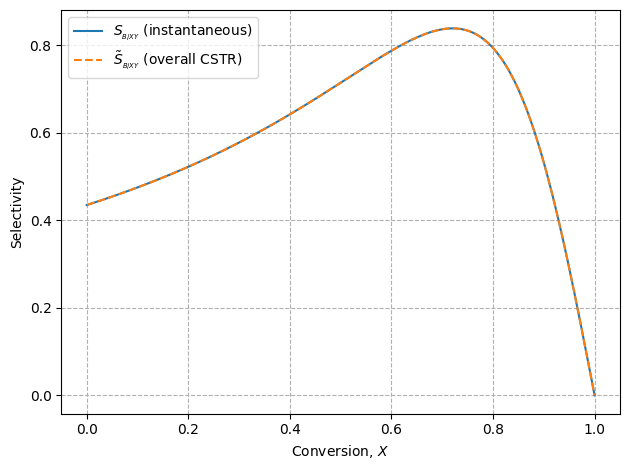

In [117]:
# calculo selectividades
rX, rB, rY = r_X(cA,T), r_B(cA,T), r_Y(cA,T)
selIns, selOvr = rB / (rX + rY), cB / (cX + cY)
indIns, indOvr = np.nanargmax(selIns), np.nanargmax(selOvr)
print(f"Selectividad instantanea  : X*= {xA[indIns]:.2f}, S*= {selIns[indIns]:.2f}")
print(f"Selectividad global (CSTR): X*= {xA[indOvr]:.2f}, S*= {selOvr[indOvr]:.2f}")
print(f"")

# Grafico
fig, ax = plt.subplots()
ax.plot(xA, selIns, label=r"$S_{_{B/XY}}$ (instantaneous)") # instantaneous
ax.plot(xA, selOvr, ls='--', label=r"$\tilde{S}_{_{B/XY}}$ (overall CSTR)") # overall
ax.set_ylabel(r"Selectivity")
ax.set_xlabel(r"Conversion, $X$")
ax.grid(ls='--')
ax.legend()
fig.tight_layout()
plt.show()


**Dimensionamiento**

In [118]:
cAstar = 1.0*cA[indOvr]
cstrTau = (cA0 - cA[indOvr]) / (-r_A(cA[indOvr], T))
cstrV = Q * cstrTau
print("Reactor CSTR:")
print(f"V: {cstrV:.2f} dm3 \nQ: {Q:.2f} dm3/s \ntau: {cstrTau:.2f} s")
print(f"cA0: {cA0:.3f} mol/dm3\ncA*: {cA[indOvr]:.3f} mol/dm3 \nX* : {xA[indOvr]:.2f} \nS* : {selOvr[indOvr]:.2f}")

Reactor CSTR:
V: 1569.33 dm3 
Q: 2.00 dm3/s 
tau: 784.66 s
cA0: 0.400 mol/dm3
cA*: 0.112 mol/dm3 
X* : 0.72 
S* : 0.84


##### Reactor PFR

**Reactor PFR:**

El uso de este reactor es menos adecuado, dado que el contenido del mismo está operando en todo el rango de conversiones desde 0 hasta $X^{*}$. La selectividad es menor que en un reactor CSTR.

**Ecuación de diseño**:

$$\tau = \frac{V}{\dot{Q}} =  - \int_{C_{\mathrm{A}}^0}^{C_{\mathrm{A}}^{*}} \frac{dC_{\mathrm{A}}}{-r_{\mathrm{A}}} = C_{\mathrm{A}}^0 \int_{0}^{X^{*}} \frac{dX_{\mathrm{A}}}{-r_{\mathrm{A}}}$$

**Curvas cinéticas y conversión**

La ecuación de tiempo espacial, $\tau$, para un PFR, es similar a la ecuación de diseño para un reactor Batch. Debajo se comprueba de forma gráfica, superponiendo (con líneas punteadas) la solución de los perfiles de concentración y de conversión de la especie $A$ sobre la solución previamente obtenida para el reactor batch.

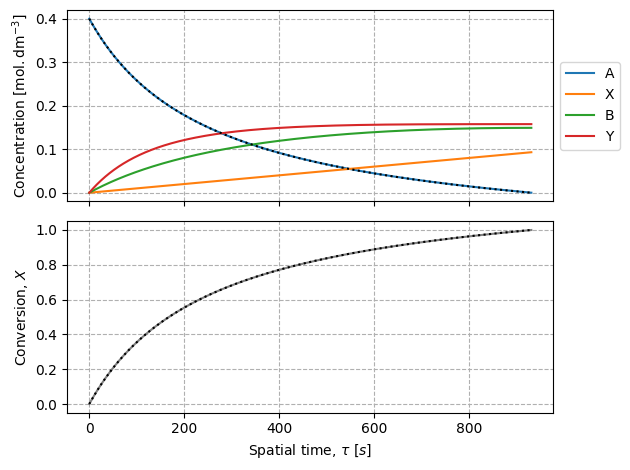

In [119]:
# Integracion de la ecuacion PFR
pfrTau = np.zeros_like(cA)
for ii, c in enumerate(cA):
    pfrTau[ii] = quad(r_A_inv, cA0, c, args=(T))[0]
pfrV = pfrTau * Q

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, sol.y):
    ax0.plot(sol.t, y, label=specie) # Batch
ax0.plot(pfrTau, cA, ls=':', color='k') # PFR
ax1.plot(sol.t, X, color='gray') # Batch
ax1.plot(pfrTau, xA, ls=':', color='k') # PFR
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Concentration [$\mathrm{mol.dm^{-3}}$]")
ax1.set_ylabel(r"Conversion, $X$")
ax1.set_xlabel(r"Spatial time, $\tau$ [$s$]")
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

**Selectividad**

En el reactor Batch, las selectividades instantanea y global son diferentes.

Selectividad instantanea : X*= 0.72, S*= 0.84
Selectividad global (PFR): X*= 0.87, S*= 0.64



/tmp/ipykernel_18579/4136888449.py:5: RuntimeWarning: invalid value encountered in divide
  selIns, selOvr = rB / (rX + rY), cB / (cX + cY)


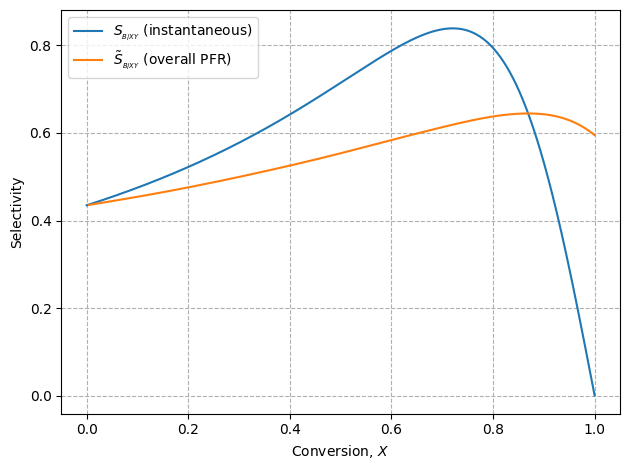

In [120]:
# calculo selectividades
rates = batch(sol.t, sol.y)
rX, rB, rY = rates[1], rates[2], rates[3]
cX, cB, cY = sol.y[1], sol.y[2], sol.y[3]
selIns, selOvr = rB / (rX + rY), cB / (cX + cY)
indIns, indOvr = np.nanargmax(selIns), np.nanargmax(selOvr)
print(f"Selectividad instantanea : X*= {X[indIns]:.2f}, S*= {selIns[indIns]:.2f}")
print(f"Selectividad global (PFR): X*= {X[indOvr]:.2f}, S*= {selOvr[indOvr]:.2f}")
print(f"")

# Grafico
fig, ax = plt.subplots()
ax.plot(X, selIns, label=r"$S_{_{B/XY}}$ (instantaneous)") # instantaneous
ax.plot(X, selOvr, label=r"$\tilde{S}_{_{B/XY}}$ (overall PFR)") # overall
ax.set_ylabel(r"Selectivity")
ax.set_xlabel(r"Conversion, $X$")
ax.grid(ls='--')
ax.legend()
fig.tight_layout()
plt.show()

**Dimensionamiento**

In [121]:
cstrTau = sol.t[indOvr]
cstrV = Q * cstrTau
print("Reactor PFR:")
print(f"V: {cstrV:.2f} dm3 \nQ: {Q:.2f} dm3/s \ntau: {cstrTau:.2f} s")
print(f"cA0: {cA0:.3f} mol/dm3\ncA*: {sol.y[0][indOvr]:.3f} mol/dm3 \nX* : {X[indOvr]:.2f} \nS* : {selOvr[indOvr]:.2f}")

Reactor PFR:
V: 1118.00 dm3 
Q: 2.00 dm3/s 
tau: 559.00 s
cA0: 0.400 mol/dm3
cA*: 0.052 mol/dm3 
X* : 0.87 
S* : 0.64


### 2.1.3 Problemática (2)

**¿Cómo se podría incrementar la conversión de $\mathrm{A}$, manteniendo una selectividad relativamente alta?**

##### Dimensionamiento

Con arreglo de reactores CSTR + PFR en serie:

- El reactor CSTR operando en condiciones que maximicen la selectividad.
- A lo largo del PFR, la conversión incrementa continuamente y la selectividad disminuye gradualmente.
- Esta combinación es un compromiso de selectividad, conversión y volumen total del arreglo de rectores.

In [122]:
##### reactor 1: CSTR hasta llegar a la selectividad máxima
cAstar = 0.112
cAcstr = np.linspace(cA0, cAstar, 1000)
cstrTau = (cA0 - cAcstr) / (-r_A(cAcstr, T)) # tiempo espacial del reactor CSTR
cstrV = Q * cstrTau
Xcstr = 1 - cAcstr/cA0 # perfil de conversion en el reactor CSTR
# concentraciones
cA = cAcstr
cX = cstrTau * r_X(cAcstr, T) 
cB = cstrTau * r_B(cAcstr, T)
cY = cstrTau * r_Y(cAcstr, T)
# selectividad
cstrSel = cB / (cX+cY)
print(f"Reactor 1 (CSTR): V={cstrV[-1]:8.2f} dm3 \tX*={Xcstr[-1]:.2f} \tS*={cstrSel[-1]:.2f}")


##### reactor 2: PFR hasta llegar a la conversión objetivo
Xtarget = 0.9
cAtarget = cA0*(1 - Xtarget)
pfrTau = quad(r_A_inv, cAstar, cAtarget, args=(T))[0] # tiempo espacial del reactor CSTR
t_span = (cstrTau[-1], cstrTau[-1]+pfrTau)
t_eval = np.linspace(t_span[0], t_span[1], 100)
C0 = (cAstar, cX[-1], cB[-1], cY[-1]) # initial concentration [mol.dm-3]
sol2 = solve_ivp(
    batch, 
    t_span, 
    y0=C0, 
    events=batchEnd, 
    t_eval=t_eval
)
Xpfr = 1 - sol2.y[0]/cA0 # perfil de conversion en el reactor PFR
# selectividad
pfrSel = sol2.y[2] / (sol2.y[1] + sol2.y[3])
print(f"Reactor 2 (PFR) : V={pfrTau*Q:8.2f} dm3 \tX*={Xpfr[-1]:.2f} \tS*={pfrSel[-1]:.2f}")

Reactor 1 (CSTR): V= 1563.72 dm3 	X*=0.72 	S*=0.84
Reactor 2 (PFR) : V=  572.62 dm3 	X*=0.90 	S*=0.82


/tmp/ipykernel_18579/2279463517.py:13: RuntimeWarning: invalid value encountered in divide
  cstrSel = cB / (cX+cY)


##### Gráficos

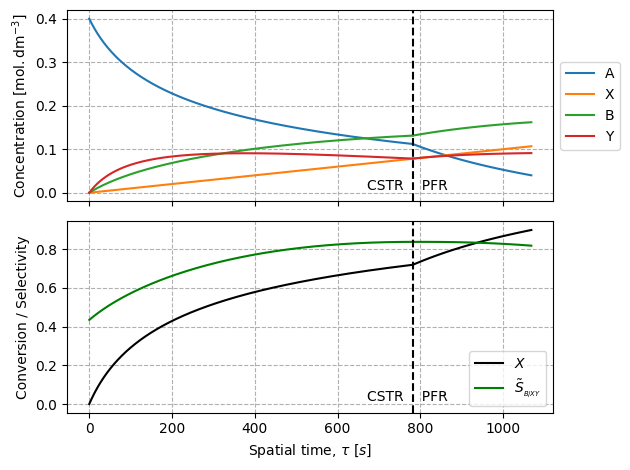

In [123]:
### Graficos
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
# concentration profiles vs spatial time
for specie, c in zip(species, [cA, cX, cB, cY]):
    ax0.plot(cstrTau, c, label=specie)
ax0.set_prop_cycle(None)
for specie, c in zip(species, sol2.y):
    ax0.plot(sol2.t, c)
# conversion vs spatial time
ax1.plot(cstrTau, Xcstr, color='k', label=r'$X$')
ax1.plot(sol2.t, Xpfr, color='k')
# selectivitiy vs spatial time
ax1.plot(cstrTau, cstrSel, color='g', label=r"$\tilde{S}_{_{B/XY}}$")
ax1.plot(sol2.t, pfrSel, color='g')


# formatting
for ax in (ax0, ax1):
    ax.axvline(cstrTau[-1], ls='--', color='k')
    ax.annotate("CSTR  ", xy=(cstrTau[-1], 0), va='bottom', ha='right')
    ax.annotate("  PFR", xy=(cstrTau[-1], 0), va='bottom', ha='left')
    ax.grid(ls='--')
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Concentration [$\mathrm{mol.dm^{-3}}$]")
ax1.legend(loc='lower right')
ax1.set_ylabel(r"Conversion / Selectivity")
ax1.set_xlabel(r"Spatial time, $\tau$ [$s$]")
fig.tight_layout()
plt.show()